# 1. Preparação do Ambiente e Carga dos Dados


1.1. Bibliotecas

In [ ]:
!pip install pandas matplotlib seaborn wordcloud streamlit


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


1.2. Carregamento de dados

In [ ]:
df = pd.read_csv("focos_br_todos-sats_2024.csv")
print( df.head())

   latitude  longitude             data_pas   satelite    pais      estado  \
0   4.27167  -60.69947  2024-01-02 02:06:00  TERRA_M-M  Brasil     RORAIMA   
1  -9.55578  -35.70564  2024-01-02 04:08:00   NPP-375D  Brasil     ALAGOAS   
2  -9.55515  -35.71013  2024-01-02 04:08:00   NPP-375D  Brasil     ALAGOAS   
3  -7.36323  -39.94515  2024-01-02 04:08:00   NPP-375D  Brasil  PERNAMBUCO   
4  -3.51178  -40.13655  2024-01-02 04:06:00   NPP-375D  Brasil       CEARÁ   

           municipio           bioma  numero_dias_sem_chuva  precipitacao  \
0          PACARAIMA        Amazônia                    7.0          0.00   
1             MACEIÓ  Mata Atlântica                 -999.0          0.00   
2             MACEIÓ  Mata Atlântica                 -999.0          0.00   
3             BODOCÓ        Caatinga                    7.0          1.32   
4  SANTANA DO ACARAÚ        Caatinga                    3.0          3.38   

   risco_fogo  id_area_industrial   frp  
0        1.00             

# 2. Limpeza  e Pré-processamento de Dados

2.1. Análise Estrutural e Dicionário de Dados

In [ ]:
print("Dimensão do DataFrame:", df.shape)
print()
print("Colunas e tipos de dados:")
print()
print(df.info())
print()
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
print("Total de duplicados:", df.duplicated().sum())


Dimensão do DataFrame: (3164620, 15)

Colunas e tipos de dados:

<class 'pandas.core.frame.DataFrame'>
Index: 3164620 entries, 0 to 3164620
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   latitude               float64       
 1   longitude              float64       
 2   data_pas               datetime64[ns]
 3   satelite               object        
 4   pais                   object        
 5   estado                 object        
 6   municipio              object        
 7   bioma                  object        
 8   numero_dias_sem_chuva  float64       
 9   precipitacao           float64       
 10  risco_fogo             float64       
 11  id_area_industrial     int64         
 12  frp                    float64       
 13  ano                    int32         
 14  mes                    int32         
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1), object(5)
memory usage: 362.2+ MB
Non

In [ ]:
# Remove a linha com bioma ausente
df = df.dropna(subset=["bioma"])

# Preenche FRP ausente com a média da própria coluna
df["frp"].fillna(df["frp"].mean(), inplace=True)

# Conferindo se ainda existem valores ausentes
print(df.isnull().sum())

2.2. Transformação de Dados e Engenharia de Features

In [ ]:
# Converte a coluna data_pas para datetime
df["data_pas"] = pd.to_datetime(df["data_pas"], errors="coerce")

# Criação de novas colunas
df["ano"] = df["data_pas"].dt.year
df["mes"] = df["data_pas"].dt.month
df["dia_semana"] = df["data_pas"].dt.day_name()

print(df[["risco_fogo", "numero_dias_sem_chuva", "precipitacao"]].describe())

         risco_fogo  numero_dias_sem_chuva  precipitacao
count  3.164620e+06           3.164620e+06  3.164620e+06
mean  -1.157900e+01           3.173613e+01  2.899424e-01
std    1.106855e+02           7.925400e+01  2.240169e+00
min   -9.990000e+02          -9.990000e+02  0.000000e+00
25%    7.600000e-01           9.000000e+00  0.000000e+00
50%    1.000000e+00           2.300000e+01  0.000000e+00
75%    1.000000e+00           5.800000e+01  0.000000e+00
max    1.000000e+00           1.200000e+02  2.529800e+02


# 4. Análise Exploratória e Visualização de Dados

3.1. Análise Temporal

[2024]


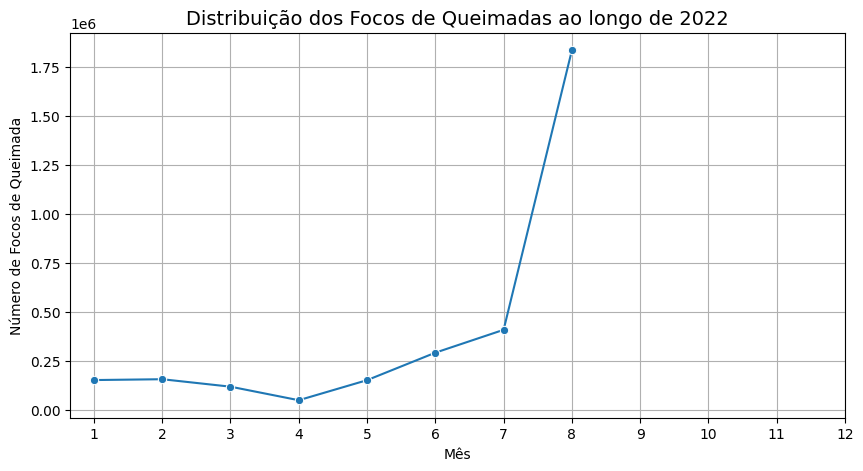

In [ ]:
print(df["ano"].unique())


# Filtra apenas os dados de 2022
df_2024 = df[df["ano"] == 2024]


# Agrupa por mês
temporal_2024 = df_2024.groupby("mes").size()


# Gráfico de linhas
plt.figure(figsize=(10,5))
sns.lineplot(x=temporal_2024.index, y=temporal_2024.values, marker="o")
plt.title("Distribuição dos Focos de Queimadas ao longo de 2022", fontsize=14)
plt.xlabel("Mês")
plt.ylabel("Número de Focos de Queimada")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


3.2. Análise Categórica

/tmp/ipython-input-2275798713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=estados.values, y=estados.index, palette="Reds_r")


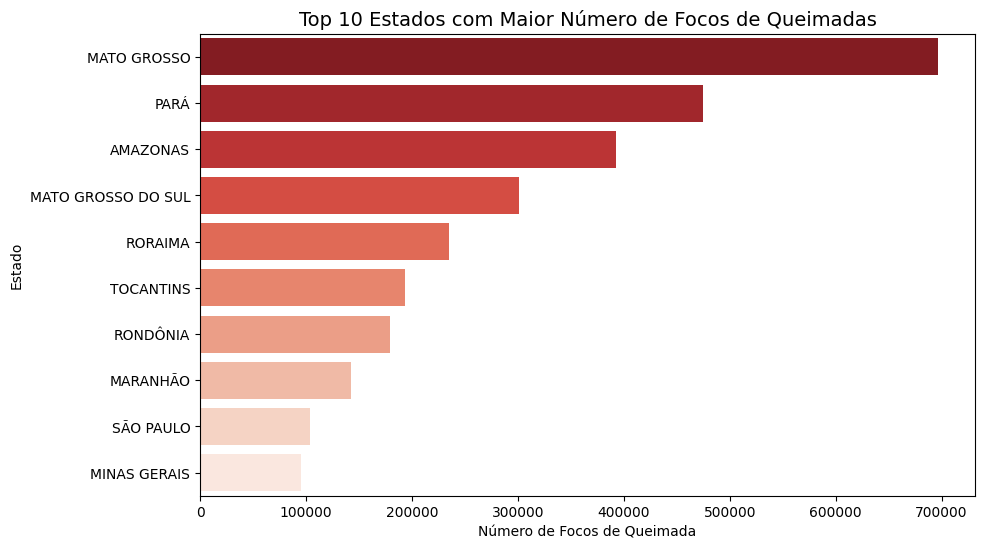

In [ ]:
#(a) Top 10 Biomas mais afetados
estados = df["estado"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=estados.values, y=estados.index, palette="Reds_r")
plt.title("Top 10 Estados com Maior Número de Focos de Queimadas", fontsize=14)
plt.xlabel("Número de Focos de Queimada")
plt.ylabel("Estado")
plt.show()


/tmp/ipython-input-566587702.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=biomas.values, y=biomas.index, palette="Oranges_r")


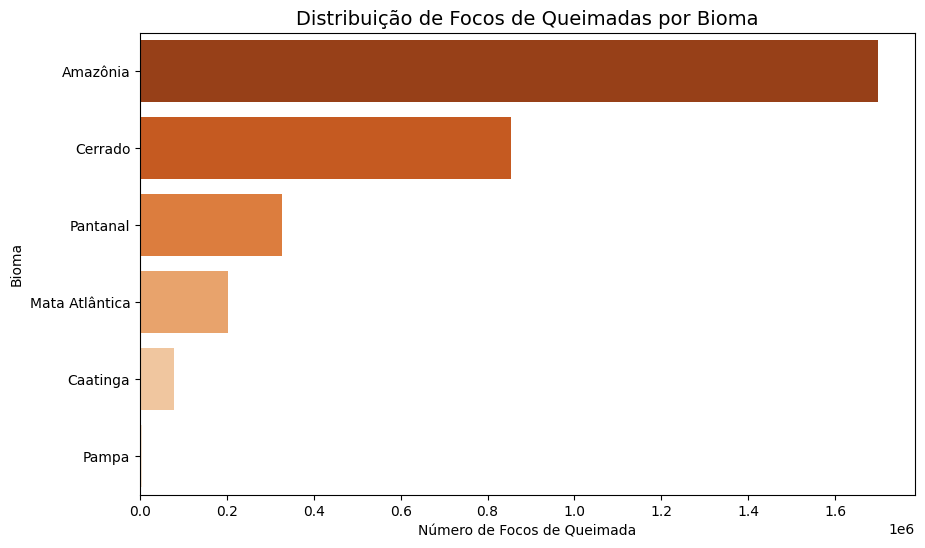

In [ ]:
# Distribuição por Biomas
biomas = df["bioma"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=biomas.values, y=biomas.index, palette="Oranges_r")
plt.title("Distribuição de Focos de Queimadas por Bioma", fontsize=14)
plt.xlabel("Número de Focos de Queimada")
plt.ylabel("Bioma")
plt.show()


In [ ]:


tabela_estados = estados.reset_index()
tabela_estados.columns = ["Estado", "Número de Focos"]
print(tabela_estados)


               Estado  Número de Focos
0         MATO GROSSO           696732
1                PARÁ           475137
2            AMAZONAS           392866
3  MATO GROSSO DO SUL           301458
4             RORAIMA           234757
5           TOCANTINS           193226
6            RONDÔNIA           179423
7            MARANHÃO           142683
8           SÃO PAULO           103713
9        MINAS GERAIS            95475


4.3. Análise Geográfica

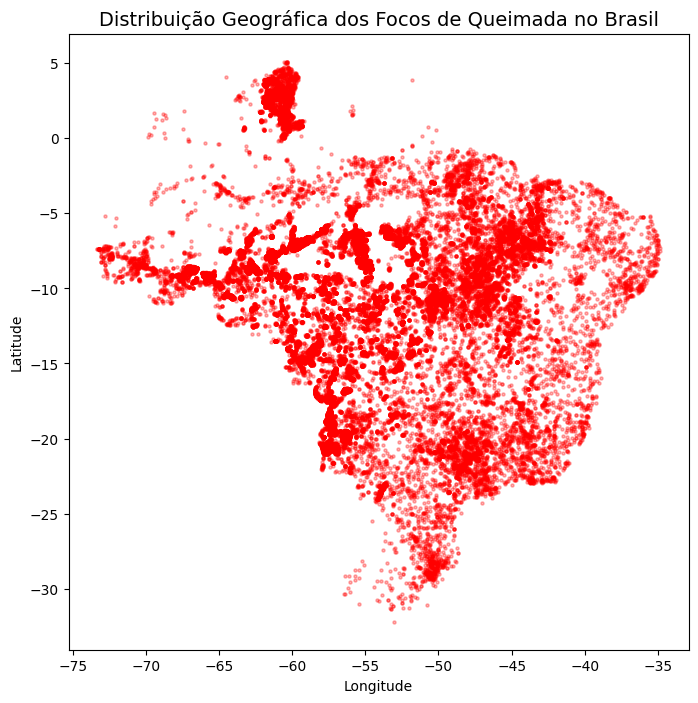

In [ ]:
# Amostra de 50 mil pontos para não travar o gráfico
amostra = df.sample(50000, random_state=42)

plt.figure(figsize=(8,8))
plt.scatter(amostra["longitude"], amostra["latitude"],
            c="red", alpha=0.3, s=5)
plt.title("Distribuição Geográfica dos Focos de Queimada no Brasil", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# Seção 6: Conclusão e Entrega do Projeto

## 6.1 Conclusão

  O estudo mostrou forte sazonalidade dos focos de calor entre agosto e outubro, concentrados principalmente no Mato Grosso, Pará e Amazonas, com maior impacto nos biomas Amazônia e Cerrado. Geograficamente, a maior incidência ocorreu na Amazônia Legal e no Cerrado, enquanto Sul e Sudeste apresentaram menor ocorrência. Entre as limitações, destacam-se a análise restrita a um único ano, a imprecisão dos dados de satélite em relação à área queimada real e a falta de integração com informações climáticas, de uso do solo e socioeconômicas. Para trabalhos futuros, sugerem-se modelagem preditiva, análises multivariadas e integração com dados de sensoriamento remoto para maior precisão e compreensão do fenômeno.


---

